In [291]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

## File Reading

In [2]:
def unpack_data(paired_list):
    labels = [label for label, _ in paired_list]
    data = [features for _, features in paired_list]
    return labels, data

In [3]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

5


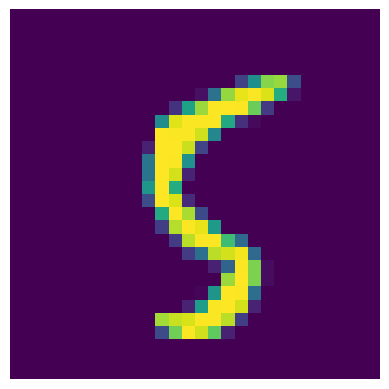

In [7]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [ ]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [9]:
def error_fractions(p_output, truths):
    wrong_answer_count = 0

    for i in range(len(p_output)):
        if p_output[i] != truths[i]:
            wrong_answer_count += 1
    
    return wrong_answer_count/len(truths)

def positives_counter(p_output, truths):
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0

    for i in range(len(p_output)):
        if p_output[i] == 1 and truths[i] == 1:
            true_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 0:
            true_negatives += 1

        elif p_output[i] == 1 and truths[i] == 0:
            false_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 1:
            false_negatives += 1

    return (true_positives, true_negatives, false_positives, false_negatives)

def precision_score(p_output, truths):
    true_positives, _, false_positives, _ = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_positives))

def recall_score(p_output, truths):
    true_positives, _, _, false_negatives = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_negatives))

def f1_score(p_output, truths):
    prec_score = precision_score(p_output, truths)
    rec_score = recall_score(p_output, truths)

    return (2 * ((prec_score * rec_score) / (prec_score + rec_score)))

## The Perceptron(s)

In [105]:
# One for each number
w0 = np.random.uniform(0, 0.5, size=785)  
w1 = np.random.uniform(0, 0.5, size=785)  
w2 = np.random.uniform(0, 0.5, size=785)  
w3 = np.random.uniform(0, 0.5, size=785)  
w4 = np.random.uniform(0, 0.5, size=785)  
w5 = np.random.uniform(0, 0.5, size=785)  
w6 = np.random.uniform(0, 0.5, size=785)  
w7 = np.random.uniform(0, 0.5, size=785)  
w8 = np.random.uniform(0, 0.5, size=785)  
w9 = np.random.uniform(0, 0.5, size=785)  

def perceptron_run(number_array, w):
    x0 = 1
    input_array = np.insert(number_array, 0, x0) 
    
    summation = np.dot(w, input_array) 

    # Activation function (step)
    output = 1 if summation > 0 else 0

    return output

#### Training Function

In [176]:
def train_perceptron(train_data_copy, w, print_flag=False):
    lr = 0.001
    num_epochs = 2000
    error_frac_threshold = 0.001
    error_frac = 1.00

    epoch_number = 0

    ones  = [item for item in train_data_copy if item[0] == 1]
    zeros = [item for item in train_data_copy if item[0] == 0]

    target_ones = len(zeros) // 2  # 1800 ones to match 3600 zeros (2:1 ratio)
    
    # Oversample ones to reach target
    ones_oversampled = ones * (target_ones // len(ones) + 1)
    ones_oversampled = ones_oversampled[:target_ones]  # Trim to exact count

    epoch_numbers = []
    error_fracs = []
    
    balanced_data = zeros + ones_oversampled
    random.shuffle(balanced_data)
    balanced_labels = np.array([item[0] for item in balanced_data])
    
    if print_flag:
        print(f"Training with {len(zeros)} zeros and {len(ones_oversampled)} ones")
        print(f"Ratio - Zeros:Ones = {len(zeros)}:{len(ones_oversampled)} ≈ {len(zeros)/len(ones_oversampled):.1f}:1")

    while(epoch_number < num_epochs):
        perc_outputs = []
        if print_flag:
            print(f"Epoch number {epoch_number + 1}", end=' ')

        # ones  = [item for item in balanced_data if item[0] == 1]
        # zeros = [item for item in balanced_data if item[0] == 0]

        # sampled_zeros = random.sample(zeros, len(ones))
        # balanced_data = sampled_zeros + ones
        random.shuffle(balanced_data)
        balanced_labels = [item[0] for item in balanced_data]

        for index in range(len(balanced_data)):
            perceptron_output = perceptron_run(balanced_data[index][1], w)
            perc_outputs.append(perceptron_output)

            error = balanced_labels[index] - perceptron_output

            w = w + (lr * (error) * (np.insert(balanced_data[index][1], 0, 1)))
            # w[0] = w[0] + (lr * error)
            # w[0] = 1

        error_frac = error_fractions(perc_outputs, balanced_labels)
        epoch_number += 1

        epoch_numbers.append(epoch_number)
        error_fracs.append(error_frac)

        if print_flag:
            print(f"Error fraction: {error_frac}", end=' ')
            print(f"Length of Data: {len(balanced_data)}", end='\n')

    return w, epoch_numbers, error_fracs

#### Model Statistics Function

In [121]:
def model_stats(testing_data_copy, w):
    perceptron_outputs = []
    true_outputs = []

    # With the train set
    for label, number in testing_data_copy:
        perceptron_outputs.append(perceptron_run(number_array=number, w=w))
        true_outputs.append(label)

    train_error_frac = error_fractions(perceptron_outputs, true_outputs)
    print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

    train_true_positives, train_true_negatives, train_false_positives, train_false_negatives = positives_counter(perceptron_outputs, true_outputs)
    print(f"True positives: {train_true_positives}, True negatives: {train_true_negatives}, False positives: {train_false_positives}, False negatives: {train_false_negatives}")

    train_prec_score = precision_score(perceptron_outputs, true_outputs)
    print(f"Precision score: {train_prec_score}")

    train_rec_score = recall_score(perceptron_outputs, true_outputs)
    print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

    train_f1_score = f1_score(perceptron_outputs, true_outputs)
    print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

    return train_error_frac, train_prec_score, train_rec_score, train_f1_score

#### Metric Comparison Bar-Plot Function

In [ ]:
def metric_comparison(w, w_trained, testing_set):
    metrics = ['Error Fraction', 'Precision', 'Recall', 'F1']

    before_error_frac, before_prec_score, before_rec_score, before_f1_score = model_stats(testing_set, w)
    after_error_frac, after_prec_score, after_rec_score, after_f1_score = model_stats(testing_set, w_trained)
    # Model 1 values
    values_1 = [before_error_frac, before_prec_score, before_rec_score, before_f1_score]

    # Model 2 values
    values_2 = [after_error_frac, after_prec_score, after_rec_score, after_f1_score]

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Bar plot for Model 1
    axes[0].bar(metrics, values_1, color='skyblue')
    axes[0].set_title('Before Training')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Score')
    axes[0].tick_params(axis='x', rotation=20)

    # Bar plot for Model 2
    axes[1].bar(metrics, values_2, color='lightgreen')
    axes[1].set_title('After Training Metrics')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    # plt.savefig(os.path.join(os.getcwd(), 'figs/metrics_before_after.png'))
    plt.show()

#### 28 x 28 Heatmap function

In [125]:
def heatmaps(w, w_trained):
    w_initial_matrix = w[1:].reshape(28, 28).T
    w_final_matrix = w_trained[1:].reshape(28, 28).T

    # Find common color scale
    vmin = min(w_initial_matrix.min(), w_final_matrix.min())
    vmax = max(w_initial_matrix.max(), w_final_matrix.max())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Before training
    im1 = ax1.imshow(w_initial_matrix, cmap='viridis', interpolation='nearest', 
                    vmin=vmin, vmax=vmax)
    ax1.set_title('Before Training')
    plt.colorbar(im1, ax=ax1, label='Value')

    # After training
    im2 = ax2.imshow(w_final_matrix, cmap='viridis', interpolation='nearest',
                    vmin=vmin, vmax=vmax)
    ax2.set_title('After Training')
    plt.colorbar(im2, ax=ax2, label='Value')

    plt.tight_layout()
    # plt.savefig(os.path.join(os.getcwd(), 'figs/heatmap.png'))
    plt.show()

#### Time Series Error Fraction Function

In [250]:
def ef_time_series(epochs, error_fracs):
    plt.plot(epochs, error_fracs)
    plt.xlabel('Epoch Number')
    plt.ylabel('Error Fraction')
    plt.title('Error Fraction Time Series')
    # plt.savefig(os.path.join(os.getcwd(), 'figs/ef_time_series.png'))

W0

In [185]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 0 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_0 = [
    (1 if label == 0 else 0, features.copy())
    for label, features in combined_test_data
]

In [ ]:
w0_trained, w0_epochs, w0_error_fracs = train_perceptron(training_data_copy, w0, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.25962962962962965 Length of Data: 5400
Epoch number 2 Error fraction: 0.08 Length of Data: 5400
Epoch number 3 Error fraction: 0.05740740740740741 Length of Data: 5400
Epoch number 4 Error fraction: 0.04574074074074074 Length of Data: 5400
Epoch number 5 Error fraction: 0.041296296296296296 Length of Data: 5400
Epoch number 6 Error fraction: 0.038148148148148146 Length of Data: 5400
Epoch number 7 Error fraction: 0.03648148148148148 Length of Data: 5400
Epoch number 8 Error fraction: 0.03518518518518519 Length of Data: 5400
Epoch number 9 Error fraction: 0.03333333333333333 Length of Data: 5400
Epoch number 10 Error fraction: 0.03166666666666667 Length of Data: 5400
Epoch number 11 Error fraction: 0.029814814814814815 Length of Data: 5400
Epoch number 12 Error fraction: 0.027407407407407408 Length of Data: 5400
Epoch number 13 Error fraction: 0.02537037037037037 Length of Data

In [186]:
model_stats(testing_data_copy_0, w0_trained)

Error Fraction: 0.023
True positives: 90, True negatives: 887, False positives: 13, False negatives: 10
Precision score: 0.8737864077669902
Recall score: 0.9
F1 score: 0.8866995073891626


(0.023, 0.8737864077669902, 0.9, 0.8866995073891626)

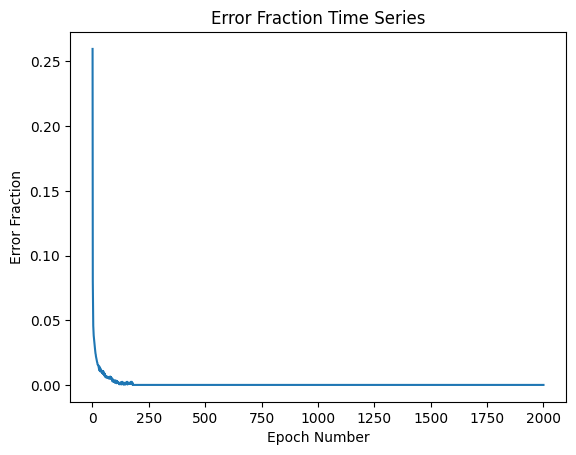

In [187]:
ef_time_series(w0_epochs, w0_error_fracs)

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.023
True positives: 90, True negatives: 887, False positives: 13, False negatives: 10
Precision score: 0.8737864077669902
Recall score: 0.9
F1 score: 0.8866995073891626


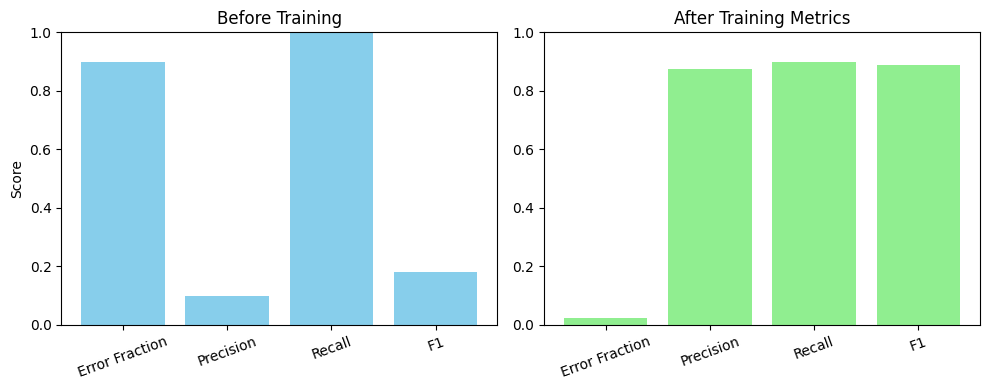

In [188]:
metric_comparison(w0, w0_trained, testing_data_copy_0)

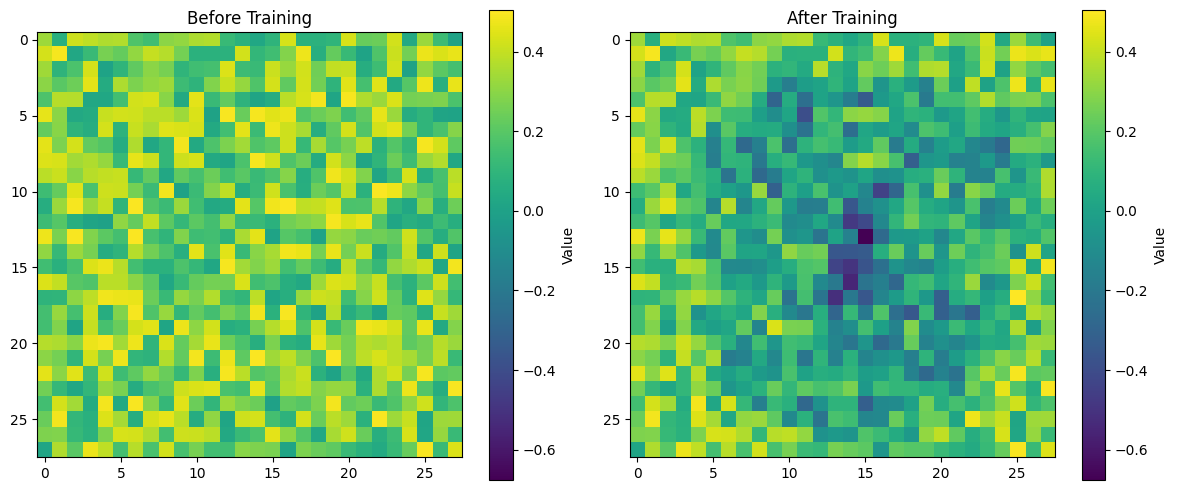

In [183]:
heatmaps(w0, w0_trained)

W1

In [191]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 1 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_1 = [
    (1 if label == 1 else 0, features.copy())
    for label, features in combined_test_data
]

In [192]:
w1_trained, w1_epochs, w1_error_fracs = train_perceptron(training_data_copy, w1, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.26814814814814814 Length of Data: 5400
Epoch number 2 Error fraction: 0.0587037037037037 Length of Data: 5400
Epoch number 3 Error fraction: 0.04 Length of Data: 5400
Epoch number 4 Error fraction: 0.032407407407407406 Length of Data: 5400
Epoch number 5 Error fraction: 0.027962962962962964 Length of Data: 5400
Epoch number 6 Error fraction: 0.027777777777777776 Length of Data: 5400
Epoch number 7 Error fraction: 0.024074074074074074 Length of Data: 5400
Epoch number 8 Error fraction: 0.023148148148148147 Length of Data: 5400
Epoch number 9 Error fraction: 0.021666666666666667 Length of Data: 5400
Epoch number 10 Error fraction: 0.022037037037037036 Length of Data: 5400
Epoch number 11 Error fraction: 0.022407407407407407 Length of Data: 5400
Epoch number 12 Error fraction: 0.020925925925925924 Length of Data: 5400
Epoch number 13 Error fraction: 0.02 Length of Data: 5400
Epoc

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.027
True positives: 90, True negatives: 883, False positives: 17, False negatives: 10
Precision score: 0.8411214953271028
Recall score: 0.9
F1 score: 0.8695652173913043


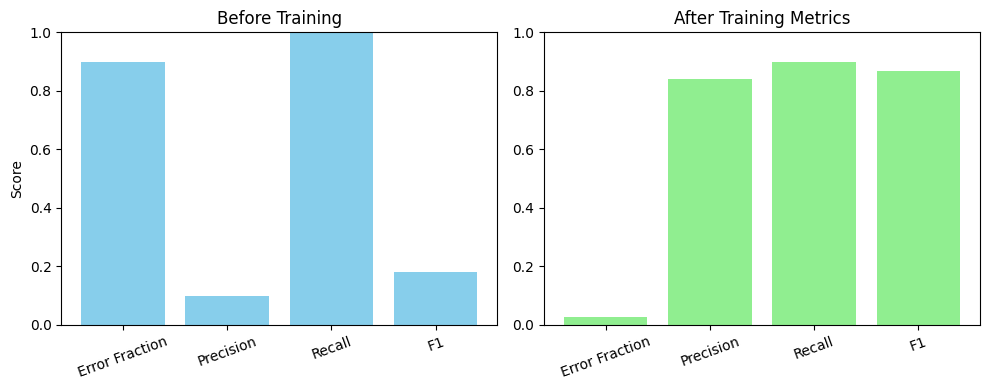

In [202]:
metric_comparison(w1, w1_trained, testing_data_copy_1)

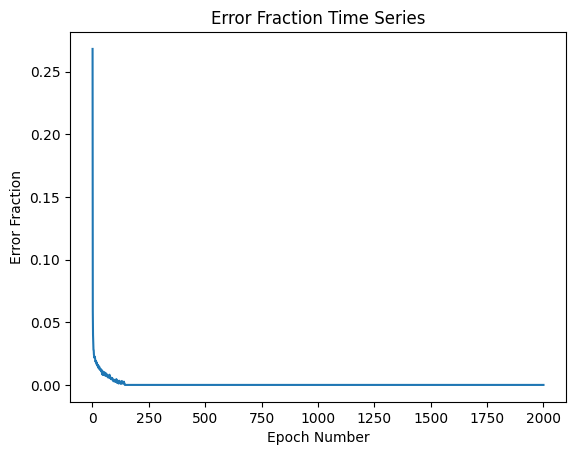

In [203]:
ef_time_series(w1_epochs, w1_error_fracs)

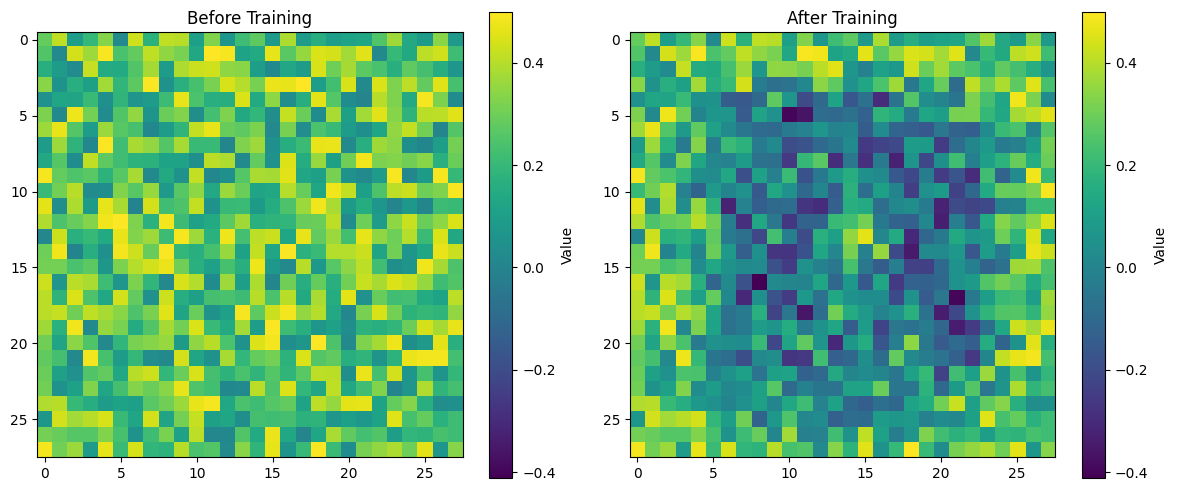

In [204]:
heatmaps(w1, w1_trained)

W2

In [205]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 2 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_2 = [
    (1 if label == 2 else 0, features.copy())
    for label, features in combined_test_data
]

In [206]:
w2_trained, w2_epochs, w2_error_fracs = train_perceptron(training_data_copy, w2, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.2903703703703704 Length of Data: 5400
Epoch number 2 Error fraction: 0.10740740740740741 Length of Data: 5400
Epoch number 3 Error fraction: 0.08962962962962963 Length of Data: 5400
Epoch number 4 Error fraction: 0.07981481481481481 Length of Data: 5400
Epoch number 5 Error fraction: 0.07388888888888889 Length of Data: 5400
Epoch number 6 Error fraction: 0.06944444444444445 Length of Data: 5400
Epoch number 7 Error fraction: 0.06537037037037037 Length of Data: 5400
Epoch number 8 Error fraction: 0.06351851851851852 Length of Data: 5400
Epoch number 9 Error fraction: 0.059814814814814814 Length of Data: 5400
Epoch number 10 Error fraction: 0.056296296296296296 Length of Data: 5400
Epoch number 11 Error fraction: 0.056296296296296296 Length of Data: 5400
Epoch number 12 Error fraction: 0.056296296296296296 Length of Data: 5400
Epoch number 13 Error fraction: 0.055185185185185184

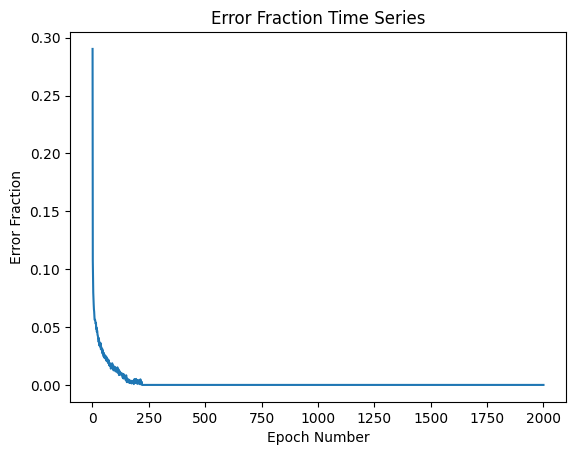

In [207]:
ef_time_series(w2_epochs, w2_error_fracs)

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.044
True positives: 82, True negatives: 874, False positives: 26, False negatives: 18
Precision score: 0.7592592592592593
Recall score: 0.82
F1 score: 0.7884615384615384


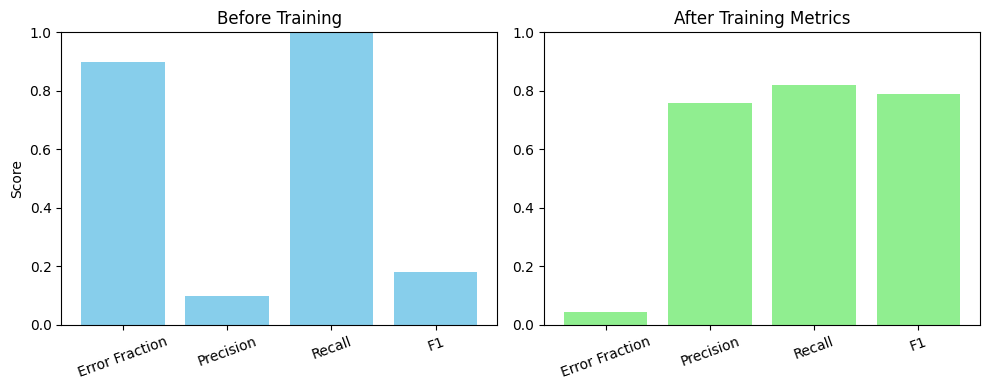

In [209]:
metric_comparison(w2, w2_trained, testing_data_copy_2)

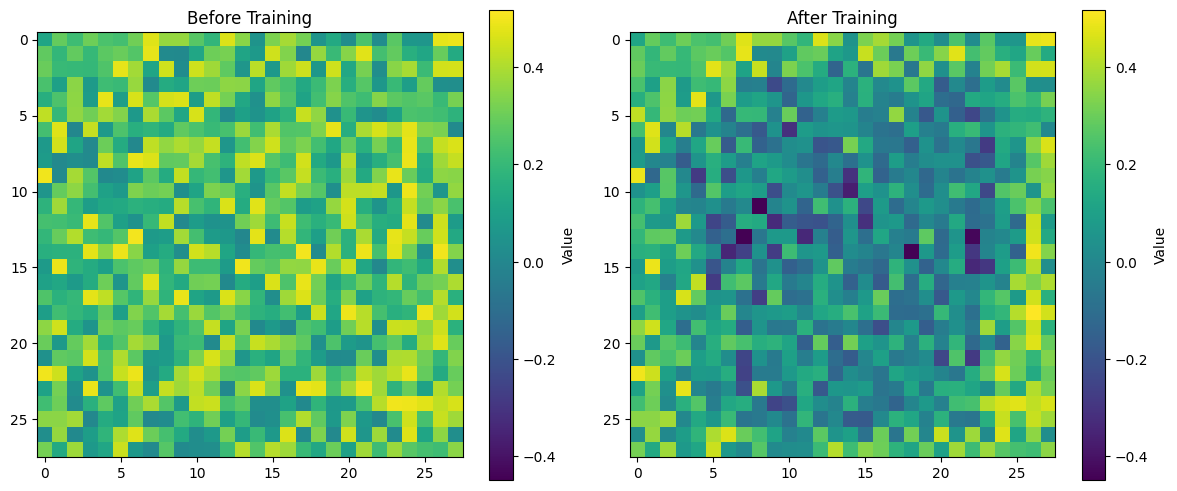

In [210]:
heatmaps(w2, w2_trained)

W3

In [211]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 3 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_3 = [
    (1 if label == 3 else 0, features.copy())
    for label, features in combined_test_data
]

In [212]:
w3_trained, w3_epochs, w3_error_fracs = train_perceptron(training_data_copy, w3, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.31592592592592594 Length of Data: 5400
Epoch number 2 Error fraction: 0.12166666666666667 Length of Data: 5400
Epoch number 3 Error fraction: 0.09259259259259259 Length of Data: 5400
Epoch number 4 Error fraction: 0.07962962962962963 Length of Data: 5400
Epoch number 5 Error fraction: 0.07629629629629629 Length of Data: 5400
Epoch number 6 Error fraction: 0.07296296296296297 Length of Data: 5400
Epoch number 7 Error fraction: 0.0674074074074074 Length of Data: 5400
Epoch number 8 Error fraction: 0.06222222222222222 Length of Data: 5400
Epoch number 9 Error fraction: 0.06074074074074074 Length of Data: 5400
Epoch number 10 Error fraction: 0.062037037037037036 Length of Data: 5400
Epoch number 11 Error fraction: 0.05907407407407408 Length of Data: 5400
Epoch number 12 Error fraction: 0.058333333333333334 Length of Data: 5400
Epoch number 13 Error fraction: 0.06018518518518518 Le

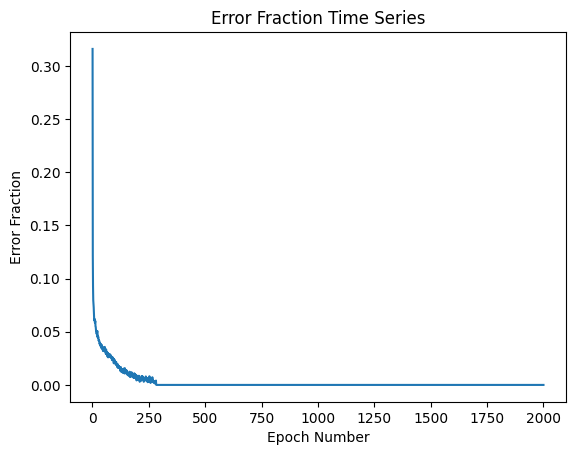

In [213]:
ef_time_series(w3_epochs, w3_error_fracs)

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.046
True positives: 80, True negatives: 874, False positives: 26, False negatives: 20
Precision score: 0.7547169811320755
Recall score: 0.8
F1 score: 0.7766990291262137


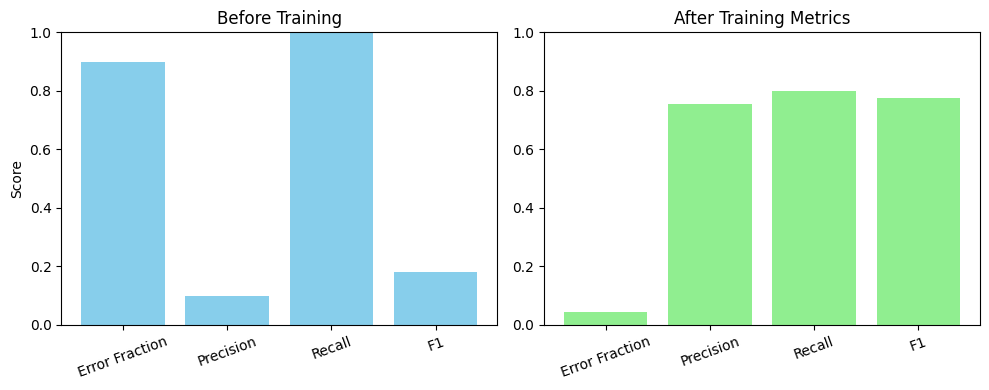

In [215]:
metric_comparison(w3, w3_trained, testing_data_copy_3)

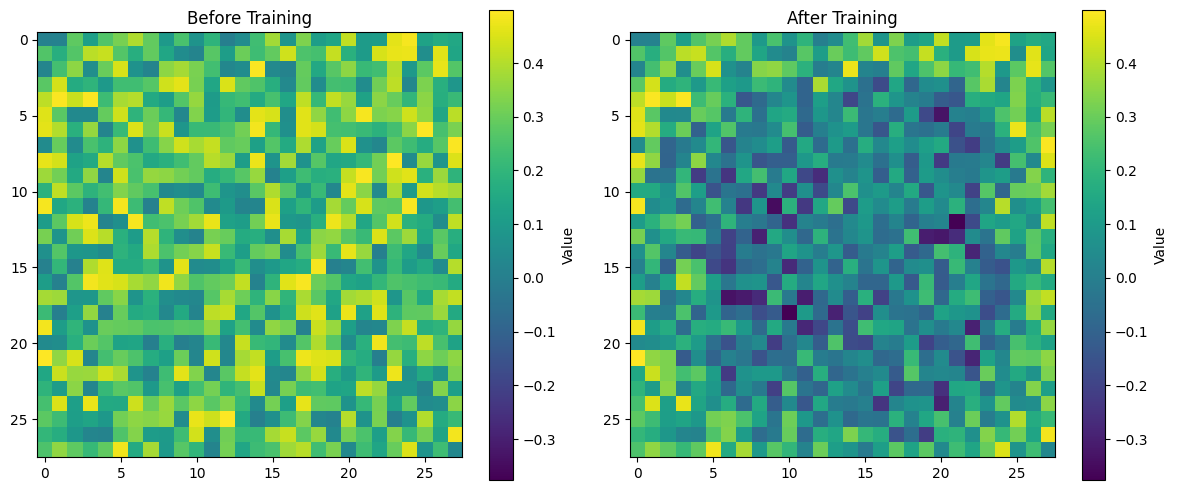

In [216]:
heatmaps(w3, w3_trained)

W4

In [217]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 4 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_4 = [
    (1 if label == 4 else 0, features.copy())
    for label, features in combined_test_data
]

In [218]:
w4_trained, w4_epochs, w4_error_fracs = train_perceptron(training_data_copy, w4, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.3277777777777778 Length of Data: 5400
Epoch number 2 Error fraction: 0.12574074074074074 Length of Data: 5400
Epoch number 3 Error fraction: 0.09296296296296297 Length of Data: 5400
Epoch number 4 Error fraction: 0.07888888888888888 Length of Data: 5400
Epoch number 5 Error fraction: 0.0687037037037037 Length of Data: 5400
Epoch number 6 Error fraction: 0.06296296296296296 Length of Data: 5400
Epoch number 7 Error fraction: 0.05962962962962963 Length of Data: 5400
Epoch number 8 Error fraction: 0.05333333333333334 Length of Data: 5400
Epoch number 9 Error fraction: 0.05074074074074074 Length of Data: 5400
Epoch number 10 Error fraction: 0.04888888888888889 Length of Data: 5400
Epoch number 11 Error fraction: 0.04777777777777778 Length of Data: 5400
Epoch number 12 Error fraction: 0.044814814814814814 Length of Data: 5400
Epoch number 13 Error fraction: 0.042222222222222223 Len

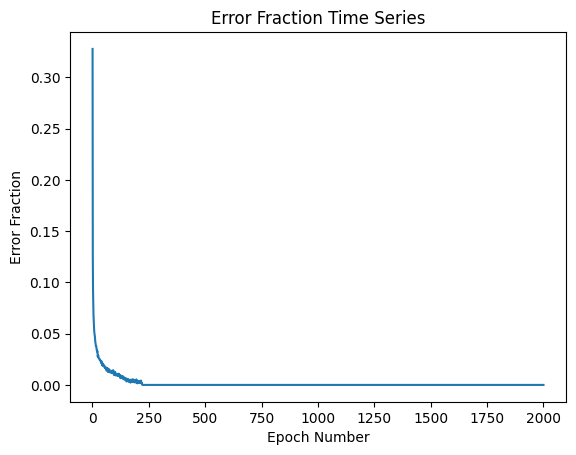

In [219]:
ef_time_series(w4_epochs, w4_error_fracs)

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.046
True positives: 79, True negatives: 875, False positives: 25, False negatives: 21
Precision score: 0.7596153846153846
Recall score: 0.79
F1 score: 0.7745098039215687


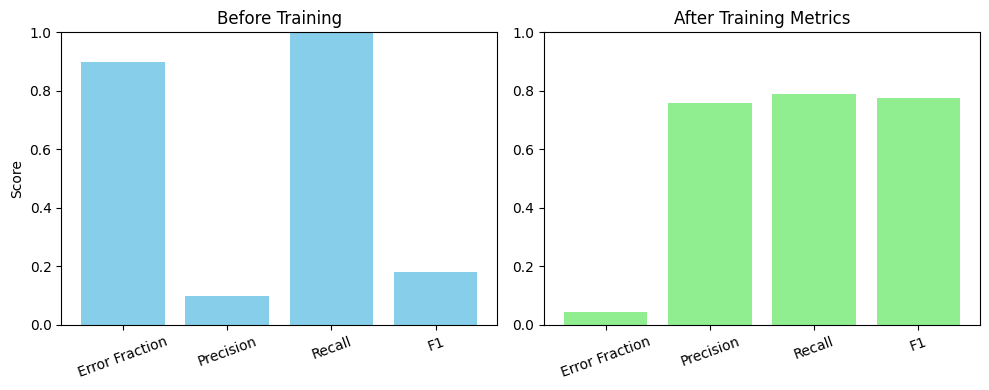

In [221]:
metric_comparison(w4, w4_trained, testing_data_copy_4)

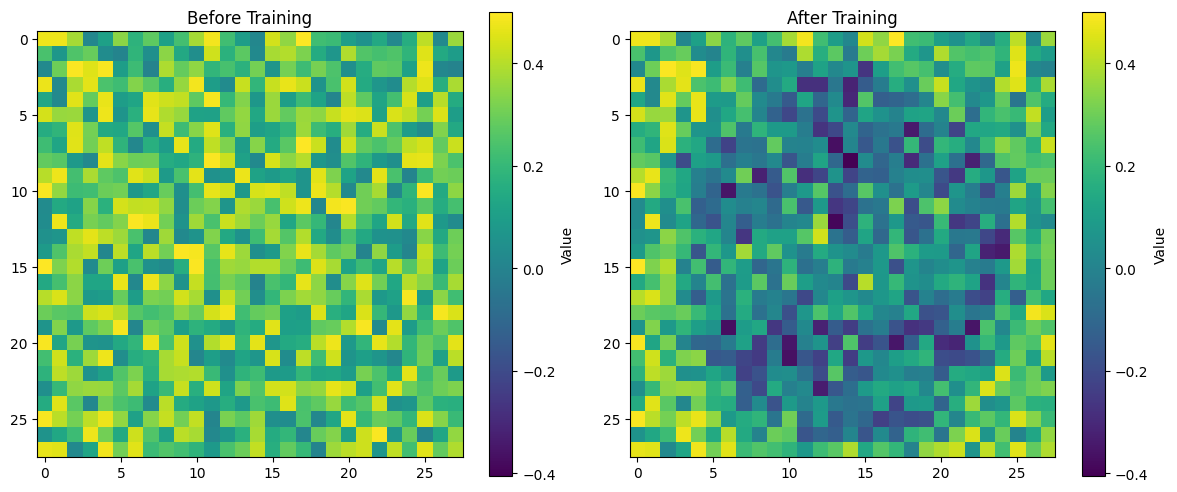

In [222]:
heatmaps(w4, w4_trained)

W5

In [278]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 5 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_5 = [
    (1 if label == 5 else 0, features.copy())
    for label, features in combined_test_data
]

In [279]:
w5_trained, w5_epochs, w5_error_fracs = train_perceptron(training_data_copy, w5, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.32925925925925925 Length of Data: 5400
Epoch number 2 Error fraction: 0.15518518518518518 Length of Data: 5400
Epoch number 3 Error fraction: 0.13185185185185186 Length of Data: 5400
Epoch number 4 Error fraction: 0.11648148148148148 Length of Data: 5400
Epoch number 5 Error fraction: 0.10666666666666667 Length of Data: 5400
Epoch number 6 Error fraction: 0.10018518518518518 Length of Data: 5400
Epoch number 7 Error fraction: 0.09759259259259259 Length of Data: 5400
Epoch number 8 Error fraction: 0.09574074074074074 Length of Data: 5400
Epoch number 9 Error fraction: 0.08611111111111111 Length of Data: 5400
Epoch number 10 Error fraction: 0.08555555555555555 Length of Data: 5400
Epoch number 11 Error fraction: 0.08185185185185186 Length of Data: 5400
Epoch number 12 Error fraction: 0.07703703703703704 Length of Data: 5400
Epoch number 13 Error fraction: 0.07629629629629629 Len

In [277]:
ef_time_series(w5_epochs, w5_error_fracs, testing_data_copy_5)

TypeError: ef_time_series() missing 1 required positional argument: 'index'

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.06
True positives: 79, True negatives: 861, False positives: 39, False negatives: 21
Precision score: 0.6694915254237288
Recall score: 0.79
F1 score: 0.7247706422018348


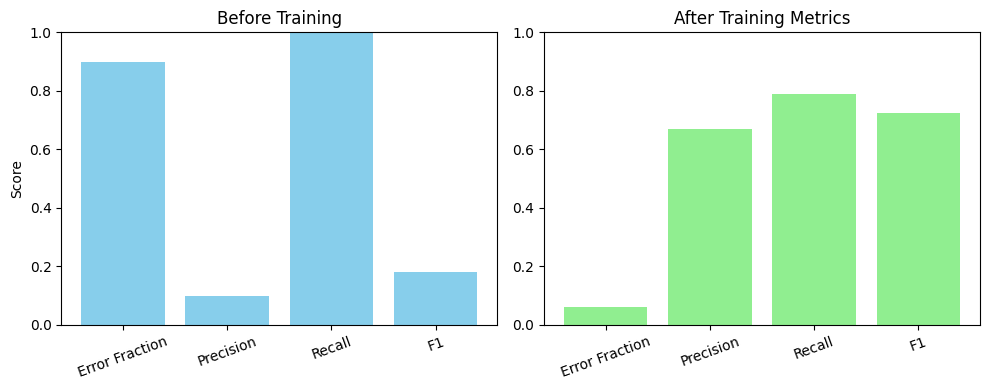

In [280]:
metric_comparison(w5, w5_trained, testing_data_copy_5)

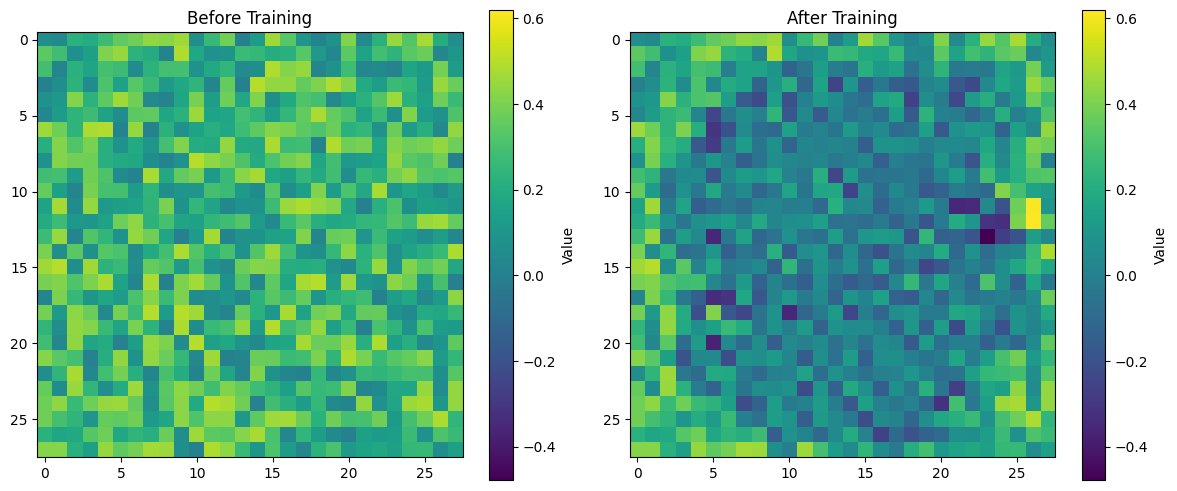

In [228]:
heatmaps(w5, w5_trained)

W6

In [242]:
training_data_copy = []

training_data_copy = [
    (1 if label == 6 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_6 = [
    (1 if label == 6 else 0, features.copy())
    for label, features in combined_test_data
]

In [230]:
w6_trained, w6_epochs, w6_error_fracs = train_perceptron(training_data_copy, w6, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.30722222222222223 Length of Data: 5400
Epoch number 2 Error fraction: 0.10074074074074074 Length of Data: 5400
Epoch number 3 Error fraction: 0.07296296296296297 Length of Data: 5400
Epoch number 4 Error fraction: 0.060925925925925925 Length of Data: 5400
Epoch number 5 Error fraction: 0.05722222222222222 Length of Data: 5400
Epoch number 6 Error fraction: 0.05296296296296296 Length of Data: 5400
Epoch number 7 Error fraction: 0.04814814814814815 Length of Data: 5400
Epoch number 8 Error fraction: 0.045 Length of Data: 5400
Epoch number 9 Error fraction: 0.042222222222222223 Length of Data: 5400
Epoch number 10 Error fraction: 0.042222222222222223 Length of Data: 5400
Epoch number 11 Error fraction: 0.03944444444444444 Length of Data: 5400
Epoch number 12 Error fraction: 0.03777777777777778 Length of Data: 5400
Epoch number 13 Error fraction: 0.03851851851851852 Length of Data

w7

In [244]:
training_data_copy = []

training_data_copy = [
    (1 if label == 7 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_7 = [
    (1 if label == 7 else 0, features.copy())
    for label, features in combined_test_data
]

In [232]:
w7_trained, w7_epochs, w7_error_fracs = train_perceptron(training_data_copy, w7, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.31166666666666665 Length of Data: 5400
Epoch number 2 Error fraction: 0.10722222222222222 Length of Data: 5400
Epoch number 3 Error fraction: 0.08703703703703704 Length of Data: 5400
Epoch number 4 Error fraction: 0.0725925925925926 Length of Data: 5400
Epoch number 5 Error fraction: 0.07092592592592592 Length of Data: 5400
Epoch number 6 Error fraction: 0.06666666666666667 Length of Data: 5400
Epoch number 7 Error fraction: 0.06555555555555556 Length of Data: 5400
Epoch number 8 Error fraction: 0.061481481481481484 Length of Data: 5400
Epoch number 9 Error fraction: 0.06018518518518518 Length of Data: 5400
Epoch number 10 Error fraction: 0.056296296296296296 Length of Data: 5400
Epoch number 11 Error fraction: 0.05425925925925926 Length of Data: 5400
Epoch number 12 Error fraction: 0.05444444444444444 Length of Data: 5400
Epoch number 13 Error fraction: 0.05425925925925926 Le

W8

In [245]:
training_data_copy = []

training_data_copy = [
    (1 if label == 8 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_8 = [
    (1 if label == 8 else 0, features.copy())
    for label, features in combined_test_data
]

In [234]:
w8_trained, w8_epochs, w8_error_fracs = train_perceptron(training_data_copy, w8, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.4072222222222222 Length of Data: 5400
Epoch number 2 Error fraction: 0.2037037037037037 Length of Data: 5400
Epoch number 3 Error fraction: 0.17814814814814814 Length of Data: 5400
Epoch number 4 Error fraction: 0.1675925925925926 Length of Data: 5400
Epoch number 5 Error fraction: 0.15296296296296297 Length of Data: 5400
Epoch number 6 Error fraction: 0.15 Length of Data: 5400
Epoch number 7 Error fraction: 0.1362962962962963 Length of Data: 5400
Epoch number 8 Error fraction: 0.1388888888888889 Length of Data: 5400
Epoch number 9 Error fraction: 0.12611111111111112 Length of Data: 5400
Epoch number 10 Error fraction: 0.12222222222222222 Length of Data: 5400
Epoch number 11 Error fraction: 0.11981481481481482 Length of Data: 5400
Epoch number 12 Error fraction: 0.11592592592592593 Length of Data: 5400
Epoch number 13 Error fraction: 0.11555555555555555 Length of Data: 5400
Ep

W9

In [246]:
training_data_copy = []

training_data_copy = [
    (1 if label == 9 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy_9 = [
    (1 if label == 9 else 0, features.copy())
    for label, features in combined_test_data
]

In [236]:
w9_trained, w9_epochs, w9_error_fracs = train_perceptron(training_data_copy, w9, print_flag=True)

Training with 3600 zeros and 1800 ones
Ratio - Zeros:Ones = 3600:1800 ≈ 2.0:1
Epoch number 1 Error fraction: 0.3887037037037037 Length of Data: 5400
Epoch number 2 Error fraction: 0.16537037037037036 Length of Data: 5400
Epoch number 3 Error fraction: 0.1312962962962963 Length of Data: 5400
Epoch number 4 Error fraction: 0.11981481481481482 Length of Data: 5400
Epoch number 5 Error fraction: 0.11018518518518519 Length of Data: 5400
Epoch number 6 Error fraction: 0.10574074074074075 Length of Data: 5400
Epoch number 7 Error fraction: 0.10185185185185185 Length of Data: 5400
Epoch number 8 Error fraction: 0.09574074074074074 Length of Data: 5400
Epoch number 9 Error fraction: 0.09351851851851851 Length of Data: 5400
Epoch number 10 Error fraction: 0.09259259259259259 Length of Data: 5400
Epoch number 11 Error fraction: 0.0875925925925926 Length of Data: 5400
Epoch number 12 Error fraction: 0.08722222222222223 Length of Data: 5400
Epoch number 13 Error fraction: 0.085 Length of Data: 5400

#### Plotting For All Perceptrons

In [264]:
def ef_time_series(ax, epochs, error_fracs, index):
    """
    Plots the error fraction time series onto a specific matplotlib Axes object (ax).
    This function is designed to be called explicitly for each subplot.
    """
    ax.plot(epochs, error_fracs)
    
    # Set the subplot title with the index (0-9)
    ax.set_title(f'W{index}', fontsize=10) 
    
    # Logic to only set labels on the bottom row and left column for clarity
    # Grid is 5 rows, 2 columns.
    # Bottom row indices: 8, 9
    if index in [8, 9]:
        ax.set_xlabel('Epoch Number', fontsize=8)
    
    # Left column indices: 0, 2, 4, 6, 8
    if index % 2 == 0:
        ax.set_ylabel('Error Fraction', fontsize=8)
    
    # Ensure y-axis is visible and ticks are readable
    ax.set_ylim(bottom=-0.01) # Set a consistent floor for better comparison
    ax.tick_params(axis='both', which='major', labelsize=7)

In [ ]:
def ten_plot():
    print("Attempting to load variables w0_... through w9_...")
    
    # Create a figure and a 5x2 grid of subplots (axes)
    fig, axes = plt.subplots(
        nrows=5,           # 5 rows
        ncols=2,           # 2 columns (5x2 grid)
        figsize=(10, 15),  # Taller figure for 5 rows
        sharex=True,       # Share the x-axis
        sharey=True        # Share the y-axis
    )

    axes_flat = axes.flatten()


    # Plot 0
    ax0 = axes_flat[0]
    ef_time_series(ax0, w0_epochs, w0_error_fracs, 0)
    
    # Plot 1
    ax1 = axes_flat[1]
    ef_time_series(ax1, w1_epochs, w1_error_fracs, 1)

    # Plot 2
    ax2 = axes_flat[2]
    ef_time_series(ax2, w2_epochs, w2_error_fracs, 2)
    
    # Plot 3
    ax3 = axes_flat[3]
    ef_time_series(ax3, w3_epochs, w3_error_fracs, 3)
    
    # Plot 4
    ax4 = axes_flat[4]
    ef_time_series(ax4, w4_epochs, w4_error_fracs, 4)
    
    # Plot 5
    ax5 = axes_flat[5]
    ef_time_series(ax5, w5_epochs, w5_error_fracs, 5)

    # Plot 6
    ax6 = axes_flat[6]
    ef_time_series(ax6, w6_epochs, w6_error_fracs, 6)

    # Plot 7
    ax7 = axes_flat[7]
    ef_time_series(ax7, w7_epochs, w7_error_fracs, 7)

    # Plot 8 (Bottom Left)
    ax8 = axes_flat[8]
    ef_time_series(ax8, w8_epochs, w8_error_fracs, 8)

    # Plot 9 (Bottom Right)
    ax9 = axes_flat[9]
    ef_time_series(ax9, w9_epochs, w9_error_fracs, 9)

    # Add a main title for the entire figure
    fig.suptitle("Error Fraction Time Series for 10 Training Runs (Plots 0-9)", fontsize=16, y=1.0)

    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    plt.savefig(os.path.join(os.getcwd(), 'figs/all_ef_time_series.png'))
    plt.show()

Attempting to load variables w0_... through w9_...


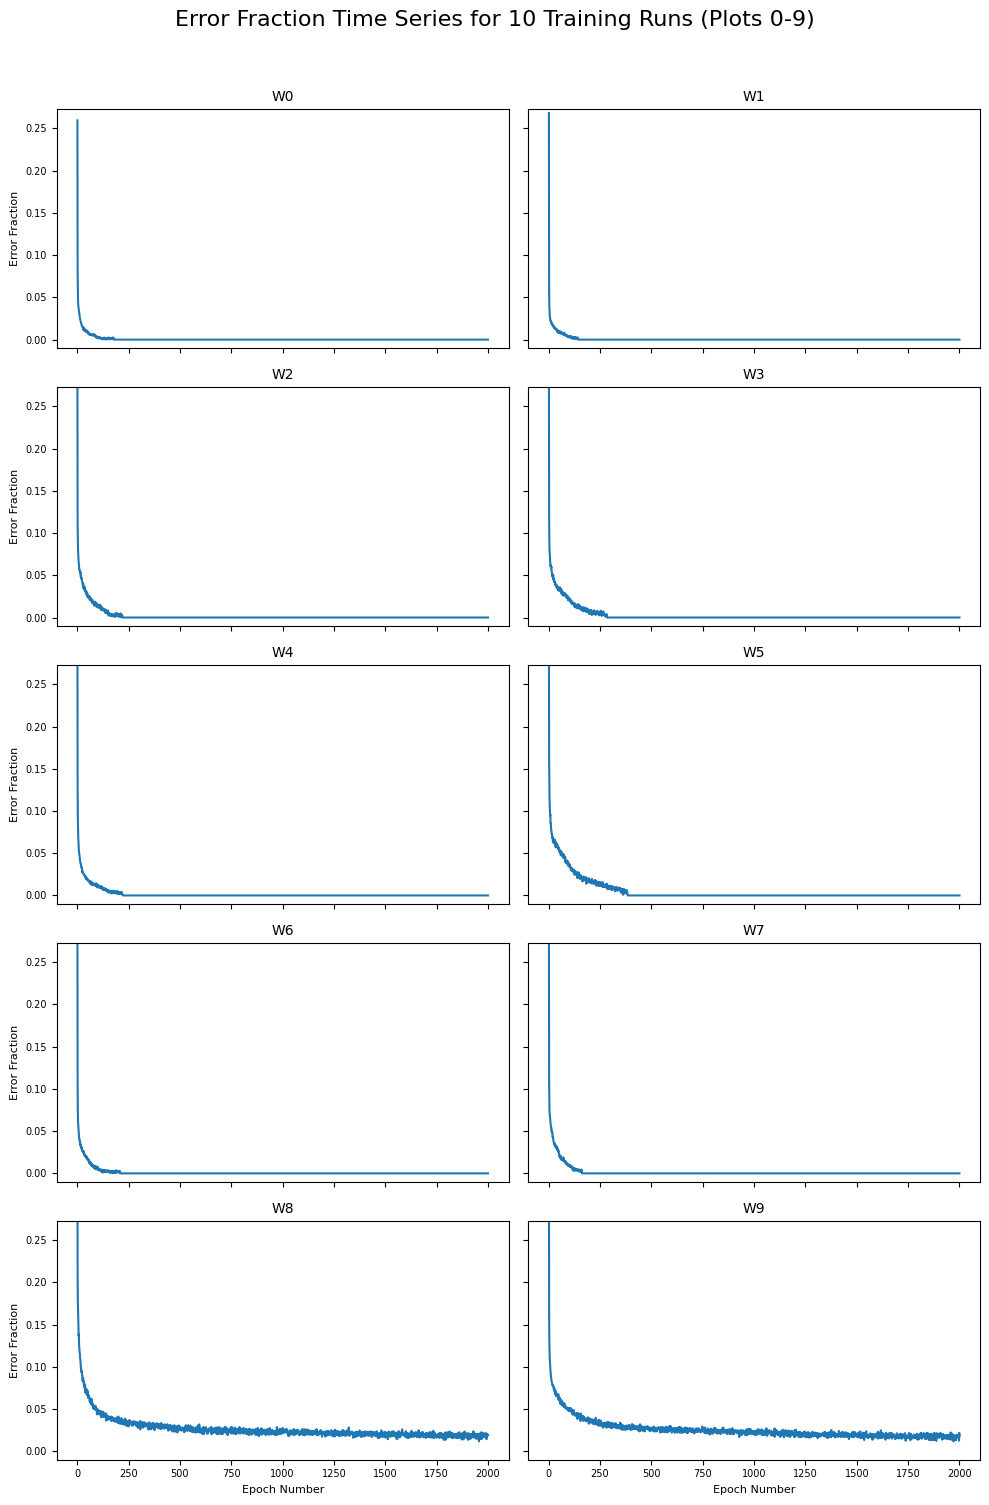

In [270]:
ten_plot()

#### Model Metric Comparison for All Perceptrons

Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.023
True positives: 90, True negatives: 887, False positives: 13, False negatives: 10
Precision score: 0.8737864077669902
Recall score: 0.9
F1 score: 0.8866995073891626
Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.027
True positives: 90, True negatives: 883, False positives: 17, False negatives: 10
Precision score: 0.8411214953271028
Recall score: 0.9
F1 score: 0.8695652173913043
Error Fraction: 0.9
True positives: 100, True negatives: 0, False positives: 900, False negatives: 0
Precision score: 0.1
Recall score: 1.0
F1 score: 0.18181818181818182
Error Fraction: 0.044
True positives: 82, True negatives: 874, False positives: 26, False negatives: 18
Precision sc

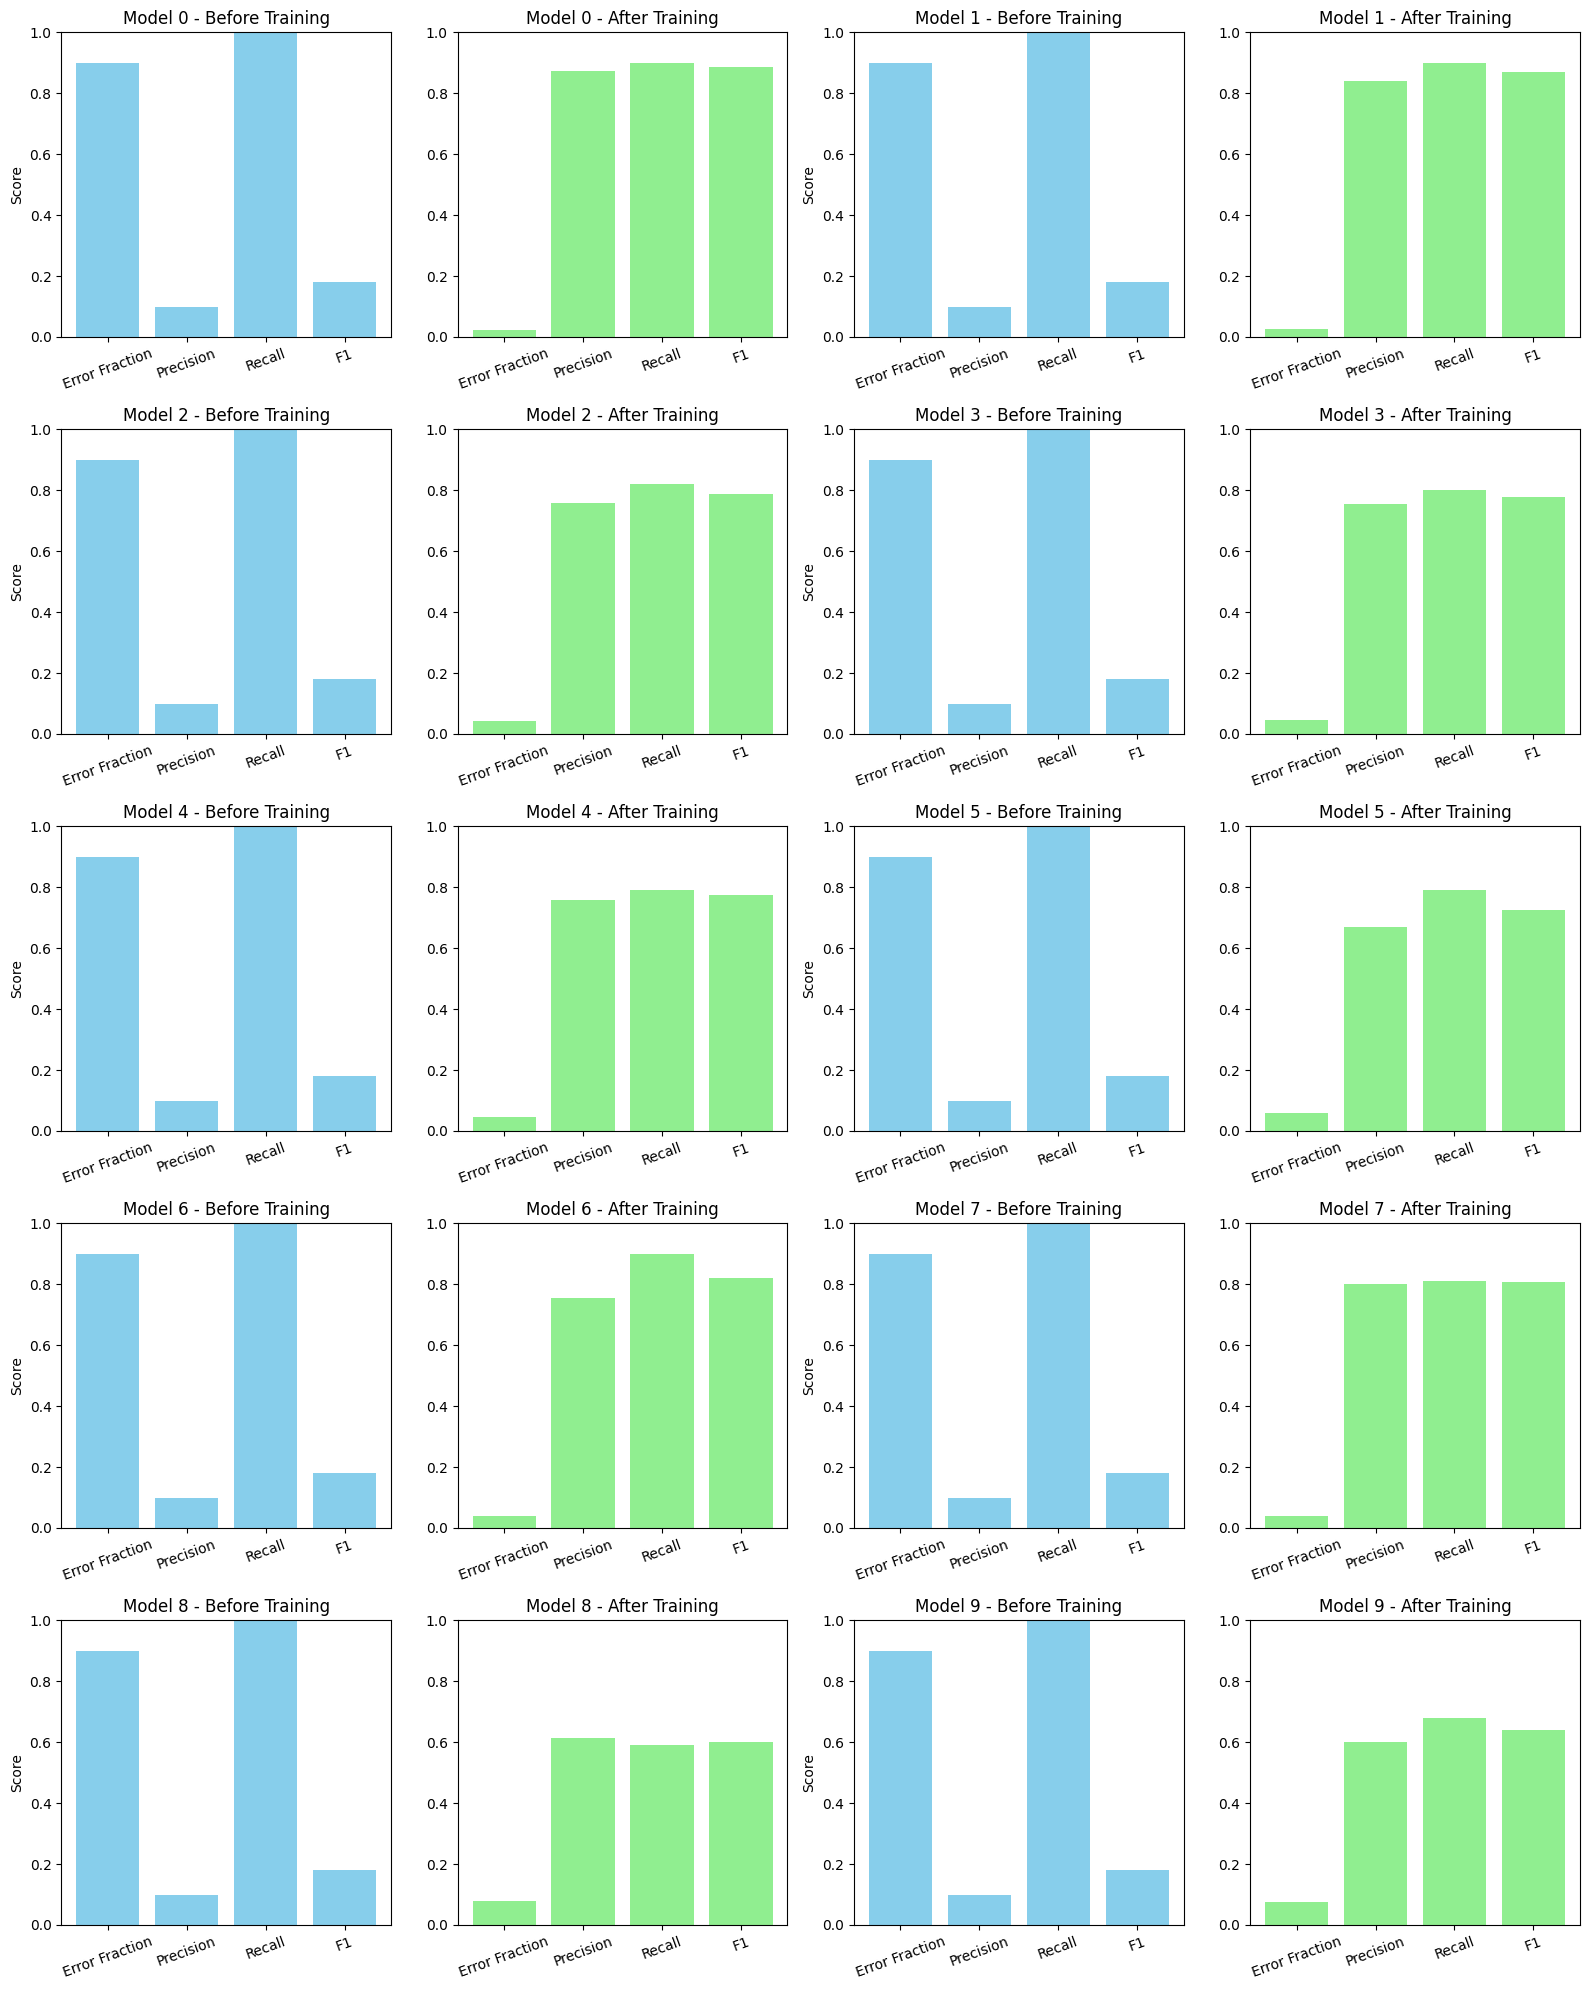

In [ ]:
def multi_metric_comparison(w_list, w_trained_list, testing_data_list):
    metrics = ['Error Fraction', 'Precision', 'Recall', 'F1']
    
    # Create 5 rows x 4 columns of subplots (2 columns per model)
    fig, axes = plt.subplots(5, 4, figsize=(16, 20))
    
    for i in range(10):
        row = i // 2
        col = (i % 2) * 2
        
        # Get metrics for this model
        before_error_frac, before_prec_score, before_rec_score, before_f1_score = \
            model_stats(testing_data_list[i], w_list[i])
        after_error_frac, after_prec_score, after_rec_score, after_f1_score = \
            model_stats(testing_data_list[i], w_trained_list[i])
        
        values_1 = [before_error_frac, before_prec_score, before_rec_score, before_f1_score]
        values_2 = [after_error_frac, after_prec_score, after_rec_score, after_f1_score]
        
        # Bar plot for Before Training (left column)
        axes[row, col].bar(metrics, values_1, color='skyblue')
        axes[row, col].set_title(f'Model {i} - Before Training')
        axes[row, col].set_ylim(0, 1)
        axes[row, col].set_ylabel('Score')
        axes[row, col].tick_params(axis='x', rotation=20)
        
        # Bar plot for After Training (right column)
        axes[row, col + 1].bar(metrics, values_2, color='lightgreen')
        axes[row, col + 1].set_title(f'Model {i} - After Training')
        axes[row, col + 1].set_ylim(0, 1)
        axes[row, col + 1].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    plt.savefig(os.path.join(os.getcwd(), 'figs/multi_metrics_before_after.png'))
    plt.show()


w_list = [w0, w1, w2, w3, w4, w5, w6, w7, w8, w9]
w_trained_list = [w0_trained, w1_trained, w2_trained, w3_trained, w4_trained, 
                  w5_trained, w6_trained, w7_trained, w8_trained, w9_trained]
testing_data_list = [testing_data_copy_0, testing_data_copy_1, testing_data_copy_2, 
                     testing_data_copy_3, testing_data_copy_4, testing_data_copy_5,
                     testing_data_copy_6, testing_data_copy_7, testing_data_copy_8, 
                     testing_data_copy_9]

# Call the function
multi_metric_comparison(w_list, w_trained_list, testing_data_list)

#### Heatmap Plotting for All Perceptrons

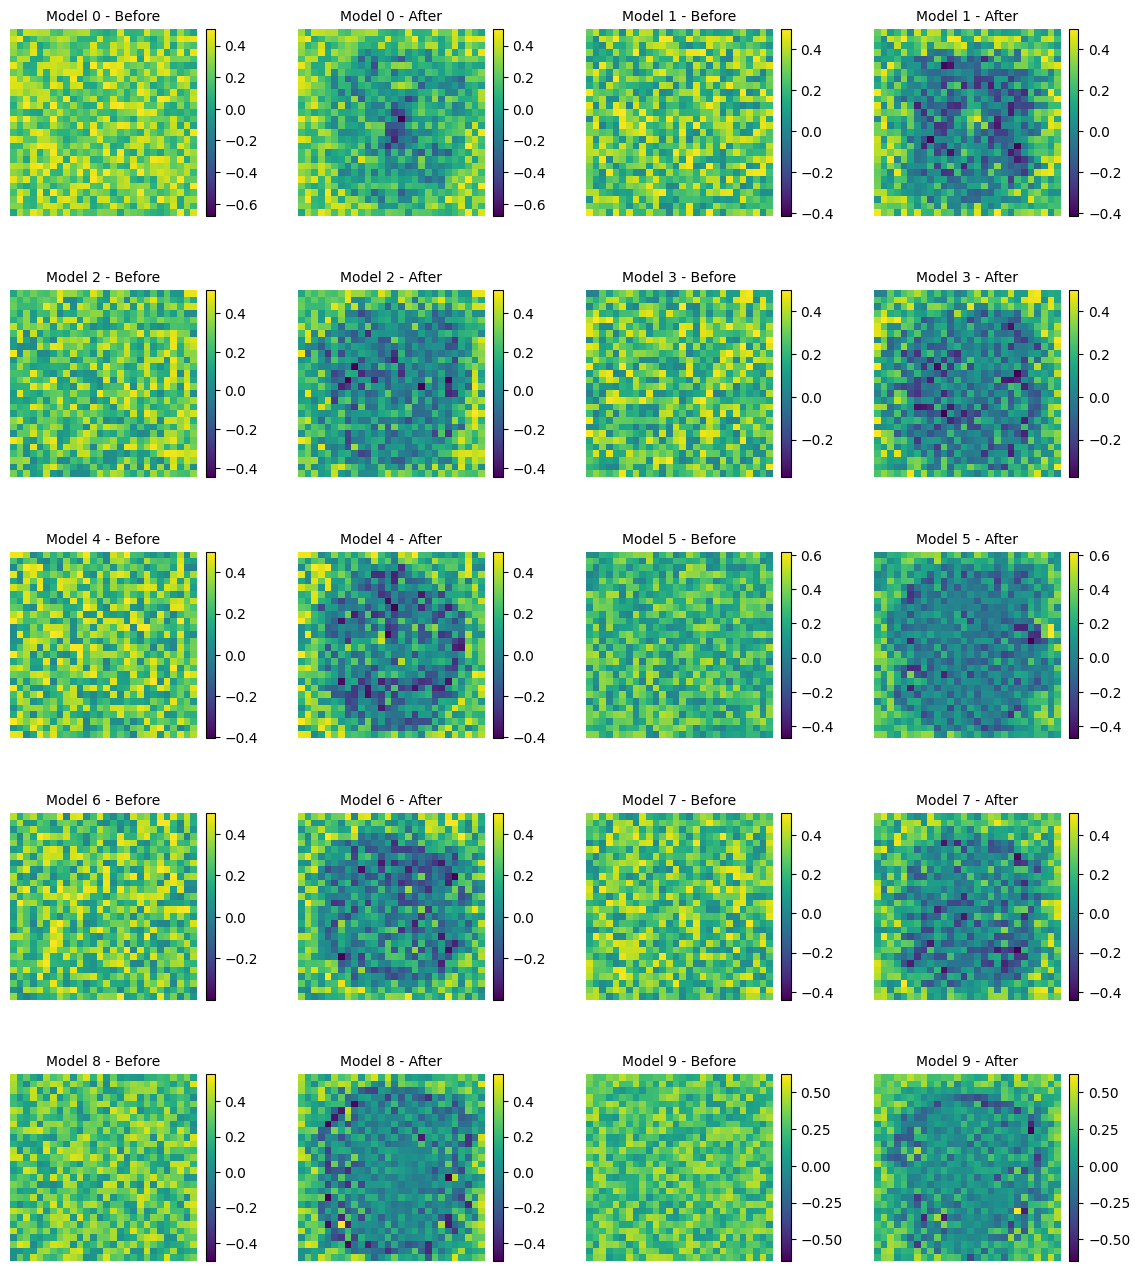

In [ ]:
def multi_heatmaps(w_list, w_trained_list):
    fig, axes = plt.subplots(5, 4, figsize=(14, 16))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    for i in range(10):
        row = i // 2
        col_base = (i % 2) * 2
        
        # Reshape weight matrices
        w_initial_matrix = w_list[i][1:].reshape(28, 28).T
        w_final_matrix = w_trained_list[i][1:].reshape(28, 28).T
        
        # Find common color scale for this model
        vmin = min(w_initial_matrix.min(), w_final_matrix.min())
        vmax = max(w_initial_matrix.max(), w_final_matrix.max())
        
        # Before training
        im1 = axes[row, col_base].imshow(w_initial_matrix, cmap='viridis', 
                                         interpolation='nearest', vmin=vmin, vmax=vmax)
        axes[row, col_base].set_title(f'Model {i} - Before', fontsize=10)
        axes[row, col_base].axis('off')
        plt.colorbar(im1, ax=axes[row, col_base], fraction=0.046, pad=0.04)
        
        # After training
        im2 = axes[row, col_base + 1].imshow(w_final_matrix, cmap='viridis', 
                                              interpolation='nearest', vmin=vmin, vmax=vmax)
        axes[row, col_base + 1].set_title(f'Model {i} - After', fontsize=10)
        axes[row, col_base + 1].axis('off')
        plt.colorbar(im2, ax=axes[row, col_base + 1], fraction=0.046, pad=0.04)
    
    plt.savefig(os.path.join(os.getcwd(), 'figs/multi_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()


w_list = [w0, w1, w2, w3, w4, w5, w6, w7, w8, w9]
w_trained_list = [w0_trained, w1_trained, w2_trained, w3_trained, w4_trained, 
                  w5_trained, w6_trained, w7_trained, w8_trained, w9_trained]

# Call the function
multi_heatmaps(w_list, w_trained_list)